# Statiscial study

## Import libraries

In [1]:
from statistic import *

The Girvan–Newman algorithm detects communities by iteratively removing the most “between” edges (bridges between groups).

Workflow

1. Compute edge betweenness centrality for every edge:
   
   $b_e = \sum_{s \ne t} \frac{\sigma_{st}(e)}{\sigma_{st}}$ where $\sigma_{st}$ is the number of shortest paths between $s$ and $t$, and $\sigma_{st}(e)$ is the number of those paths that go through edge $e$.
2. Remove the edge(s) with the highest betweenness.
3. Recompute betweenness on the new graph and repeat. This yields a hierarchy of partitions with an increasing number of communities.
4. Score each partition by modularity and select the best level:
   
   $$Q = \frac{1}{2m} \sum_{i,j} \Big(A_{ij} - \frac{k_i k_j}{2m}\Big) \, \delta(c_i, c_j)$$
   where $A_{ij}$ is the adjacency, $k_i$ is the degree of node $i$, $m$ is the total number of edges, and $\delta(c_i,c_j)=1$ if nodes $i$ and $j$ are in the same community.

Notes
- We evaluate partitions using NetworkX’s modularity and pick the maximum-$Q$ split (no need to predefine the number of clusters).
- Our visualization reuses the earlier function: nodes are colored by community, edges by weight with a colorbar.

In [ ]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import modularity as nx_modularity

def run_gn_select_by_modularity(G, max_levels=20, weight='weight'):
    """Run Girvan-Newman and select best partition by modularity up to max_levels.
    
    Parameters
    ----------
    G : networkx.Graph
        max_levels : int
            Maximum number of levels to explore.
        weight : str or None
            Edge attribute for weights. If None, unweighted.
    Returns
    -------
    dict with keys:
        'best_partition' : tuple of sets
        'best_Q' : float
        'history' : list of dicts with keys 'level', 'n_comm', 'Q', 'communities'
    """
    H = G.to_undirected() if G.is_directed() else G
    comp_gen = girvan_newman(H)
    history = []
    best = None
    for level, communities in enumerate(comp_gen, start=1):
        comms = tuple(sorted((set(c) for c in communities), key=lambda s: min(s)))
        Q = nx_modularity(H, comms, weight=weight)
        record = {'level': level, 'n_comm': len(comms), 'Q': Q, 'communities': comms}
        history.append(record)
        if best is None or Q > best['Q'] or (Q == best['Q'] and len(comms) < best['n_comm']):
            best = record
        if level >= max_levels or len(comms) >= H.number_of_nodes():
            break
    return {'best_partition': best['communities'], 'best_Q': best['Q'], 'history': history}

if 'girvan_newman' in methods:
    gn_result = run_gn_select_by_modularity(G, max_levels=30, weight='weight')
    node_order = sorted(G.nodes())

    try:
        gn_best = gn_result['best_partition']
        gn_Q = gn_result['best_Q']
        gn_hist = gn_result['history']
        gn_best_labels = communities_to_labels(gn_best, node_order)
        print(f"GN best: Q={gn_Q:.4f}, communities={len(gn_best)}")
    except Exception as e:
        print('GN labeling failed:', e)

    if plot_perf:
        x = [h['n_comm'] for h in gn_hist]; y = [h['Q'] for h in gn_hist]
        plt.figure(figsize=(6,4))
        plt.plot(x, y, 'o-')
        plt.xlabel('# Communities'); plt.ylabel('Modularity Q'); plt.title('Girvan–Newman: modularity vs #communities')
        plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    visualize_graph(G, gn_best_labels, title=f"Girvan–Newman partition (Q={gn_Q:.3f}, k={len(gn_best)})")

    nodes_ordered = sorted(G.nodes())
    
    print("\n--- Export Girvan-Newman ---")
    export_clusters(
        df=df, 
        labels=gn_best_labels, 
        node_ids=nodes_ordered, 
        method_name='girvan_newman', 
        subset_name=subset
    )

In [ ]:
df

### Comparison Output Explained
This table summarizes how similar the two community partitions (Louvain vs Girvan–Newman) are. Higher values mean closer agreement.

- Rand: fraction of node pairs on which the methods agree (same cluster or different clusters). Range [0, 1].
- Adjusted Rand (ARI): Rand index corrected for chance; 0 ≈ random, 1 = identical; can be negative if worse than random.
- Jaccard (pair-counting): among pairs co-assigned by at least one method, the fraction co-assigned by both. Range [0, 1].
- NMI: normalized mutual information between labelings; invariant to label permutations. 0 = independent, 1 = identical.

Below the table, the printed line shows how many communities each method found (useful context when interpreting the scores).

In [10]:
# Compare Louvain vs Girvan–Newman partitions using clustering similarity metrics
from sklearn.metrics import rand_score, adjusted_rand_score, normalized_mutual_info_score

def jaccard_partition(y1, y2):
    """Pair-counting Jaccard similarity between two cluster labelings.
    Matches the definition used in exercise10 (counts co-assigned pairs)."""
    y1 = np.asarray(y1)
    y2 = np.asarray(y2)
    N = len(y1)
    S = 0  # pairs in same cluster in both
    D = 0  # pairs in different clusters in both
    for i in range(N):
        for j in range(i):
            same1 = (y1[i] == y1[j])
            same2 = (y2[i] == y2[j])
            if same1 and same2:
                S += 1
            if (not same1) and (not same2):
                D += 1
    total_pairs = N * (N - 1) / 2
    if total_pairs == D:
        return 0.0
    return S / (total_pairs - D)

# Ensure both label arrays exist and align in length
assert 'best_labels' in globals(), "Louvain labels 'best_labels' not found"
assert 'gn_best_labels' in globals(), "GN labels 'gn_best_labels' not found"
assert len(best_labels) == len(gn_best_labels), "Label arrays must have same length"

y_louvain = np.asarray(best_labels)
y_gn = np.asarray(gn_best_labels)

metrics = {
    'Rand': rand_score(y_louvain, y_gn),
    'Adjusted Rand (ARI)': adjusted_rand_score(y_louvain, y_gn),
    'Jaccard (pair-counting)': jaccard_partition(y_louvain, y_gn),
    'NMI': normalized_mutual_info_score(y_louvain, y_gn)
}
df_metrics = pd.DataFrame(metrics, index=['Louvain vs GN']).T
display(df_metrics)

# Optional: quick sanity display of community counts
print(f"Louvain communities: {len(np.unique(y_louvain))}, GN communities: {len(np.unique(y_gn))}")

AssertionError: GN labels 'gn_best_labels' not found

**FINAL OUTPUT:** different clusters (subsets of predictions) with insights.
for each cluster, generate the following outputs:
- most common words
- most common signs
- most common topics
- a .csv file, subset of *horoscope_full.csv* with all predictions in the cluster.
- find the *'original prediction'*: the prediction that is the most similar to the other elements of the cluster, and (manually) check if the cluster makes sense

## Use

In [3]:
analyze_clusters_statistics('wellness_louvain.h5', min_cluster_size=2)

Loading file: wellness_louvain.h5...
 Analyzing 1024 significant clusters...
 Calculating keywords & Aggregating text...
 Generating detailed report...

ANALYSIS RESULTS (Top 10 Clusters by size)
 Cluster ID  Size                                                Keywords  Dominant Sign                                                   IDS                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

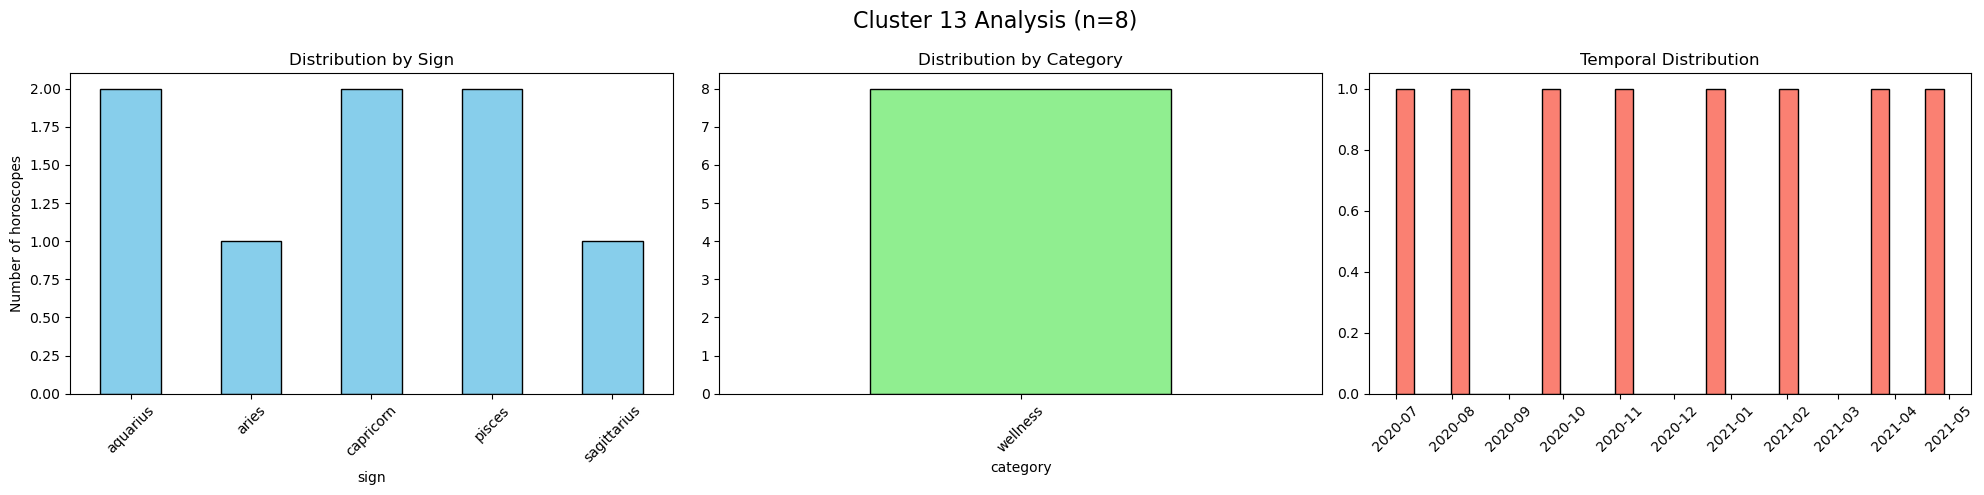

In [4]:
plot_cluster_details('wellness_louvain.h5', cluster_id=13)

In [5]:
new_stats = add_advanced_statistics('wellness_louvain.h5', min_cluster_size=2)

Loading file: wellness_louvain.h5...
Calculating advanced statistics for 1024 clusters...

TOP 10 MOST COHERENT CLUSTERS


,Cluster,Size,Avg Words/Text,Lexical Diversity,Semantic Cohesion
512,3309,4,69.0,0.88,1.0
688,146,4,88.0,0.78,1.0
675,159,4,77.0,0.79,1.0
676,158,4,85.0,0.75,1.0
677,157,4,71.0,0.89,1.0
678,156,4,78.0,0.78,1.0
679,155,4,79.0,0.84,1.0
680,154,4,76.0,0.78,1.0
681,153,4,85.0,0.75,1.0
682,152,4,74.0,0.76,1.0
